## В этом задании необходимо будет дореализовать ключевые формулы для обучения дискретной [ddpm](https://arxiv.org/pdf/2006.11239.pdf).  


---
Для выполнения домашнего задания достаточно использовать Google Colab.


Ваше ФИО: _________Шурыгин Всеволод Евгеньевич

In [ ]:
!python3 -V
import torch


print(f'torch.__version__: {torch.__version__}')

Python 3.12.12
torch.__version__: 2.8.0+cu126


In [ ]:
!pip3 install wandb torch_ema denoising_diffusion_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.7/83.7 kB 4.5 MB/s eta 0:00:00


## Dataset

In [ ]:
import random
import numpy as np

from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Dataset
from typing import Generator, Tuple, Dict, Optional, Union
from torch import Tensor
from cv2 import resize


def set_global_seed(seed: int) -> None:
    """
    Set global seed for reproducibility.
    """

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def preprocess_image(image: "PIL.Image") -> np.ndarray:
    image = np.array(image, dtype=np.uint8)
    image = resize(image, (32, 32))
    return np.array(image, dtype=np.float32) / 127.5 - 1


def postprocess_image(image: torch.Tensor) -> torch.Tensor:
    # convert values to [0; 255]
    image = image.cpu().detach()
    image = (image + 1) * 127.5
    image = torch.clip(image, 0, 255)
    return image


class MnistDataset(Dataset):
    def __init__(self, train: bool = True):
        super().__init__()
        self.mnist = MNIST(
            'data',
            train=train,
            download=True
        )

    def __len__(self) -> int:
        return len(self.mnist)

    def __getitem__(self, index: int) -> Dict[str, Tensor]:
        image, target = self.mnist[index]
        image = preprocess_image(image)
        target = int(target)
        return {
            "images": Tensor(image)[None],
            "targets": target
        }

In [ ]:
def dict_to_device(dct: Dict[str, Tensor], device: torch.device) -> Dict[str, Tensor]:
    return {k: v.to(device) for k, v in dct.items()}


def get_train_images_generator(
    batch_size: int = 128,
    num_workers: int = 0,
    shuffle: bool = True,
    drop_last: bool = True
) -> Generator[Dict[str, Tensor], None, None]:
    dataset = MnistDataset(train=True)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        drop_last=drop_last
    )
    while True:
        yield from loader

In [ ]:
def check_generator(batch_size: int = 128):
    generator = get_train_images_generator(batch_size)
    batch_dict = next(generator)
    assert(batch_dict['images'].shape == (batch_size, 1, 32, 32), batch_dict['images'].shape)
    assert(batch_dict['targets'].shape == (batch_size,), batch_dict['targets'].shape)

check_generator(131)

<>:4: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:5: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:4: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:5: SyntaxWarning: assertion is always true, perhaps remove parentheses?
/tmp/ipython-input-2113533935.py:4: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert(batch_dict['images'].shape == (batch_size, 1, 32, 32), batch_dict['images'].shape)
/tmp/ipython-input-2113533935.py:5: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert(batch_dict['targets'].shape == (batch_size,), batch_dict['targets'].shape)
100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 522kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.76MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.87MB/s]


## DDPM's dynamic, 5 pts



В `get_coeffs_primities` (2 pts) необходимо в возвращаеый словарь добавить рассчет коэффицентов, при помощи которых вы сможете реализовать семплирование из распределений $q(x_t | x_0), q(x_t | x_{t+1}, x_0), p(x_t | x_{t + 1})$.

Например:
- $\alpha_t = 1 - \beta_t$
- $\bar{\alpha_t} = \prod_{t=1}^{T} \alpha_t$
- $\sqrt{\bar{\alpha_t}}$
- ...
- любые коэффиценты, которые помогут вам рассчитать коэффиценты в $q(x_t | x_0), q(x_t | x_{t+1}, x_0), p(x_t | x_{t + 1})$

`extract_values_from_times` - по батчу с целочислненными временами выдает батч коэфиицентов в нужном шейпе для перемножения с батчом картинок


In [ ]:
from torch import nn


def get_coeffs_primitives(
    T: int = 1000,
    beta_min: float = 1e-4,
    beta_max: float = 2e-2,
) -> Dict[str, Tensor]:
    """
    output: Dict[str, Tensor]
      {
        "a": b
      }
    ---
    b.shape == (T,)
    """
    betas = torch.linspace(beta_min, beta_max, T).float()
    alphas = 1 - betas

    sqrt_alphas = torch.sqrt(alphas)
    alphas_hat = torch.cumprod(alphas, dim=0)

    alphas_hat_prev = torch.cat([torch.FloatTensor([1.]), alphas_hat[:-1]])

    sqrt_alphas_hat = torch.sqrt(alphas_hat)
    sqrt_1m_alphas_hat = torch.sqrt(1 - alphas_hat)
    posterior_mu_x0_coef = torch.sqrt(alphas_hat_prev) * betas / (1 - alphas_hat)
    posterior_mu_xt_coef = sqrt_alphas * (1 - alphas_hat_prev) / (1 - alphas_hat)
    posterior_std = torch.sqrt((1 - alphas_hat_prev) / (1 - alphas_hat) * betas)

    return {
        "betas": betas,
        "alphas": alphas,
        "alphas_hat": alphas_hat,
        "sqrt_alphas_hat": sqrt_alphas_hat,
        "sqrt_1m_alphas_hat": sqrt_1m_alphas_hat,
        "posterior_mu_x0_coef": posterior_mu_x0_coef,
        "posterior_mu_xt_coef": posterior_mu_xt_coef,
        "posterior_std": posterior_std,
    }


def extract_values_from_times(values: Tensor, times: torch.LongTensor) -> Tensor:
    values = values[times]
    return values[:, None, None, None]


`DDPMDynamic`: (3 pts)
- `__init__` - получаем коэффиценты, добавляем их в класс, как атрибуты, чтобы доставать их по имени без использования словаря
- `sample_from_posterior_q(x_t: FloatTensor, x_0: FloatTensor, t: LongTensor)` - $ x_{t-1} \sim q(x_{t-1} | x_{t}, x_0) $
- `forward` - $ x_{t} \sim q(x_t | x_0) $

In [ ]:
class DDPMDynamic(nn.Module):
    def __init__(
        self,
        T: int = 1000,
        beta_min: float = 1e-4,
        beta_max: float = 2e-2,
    ):
        super().__init__()
        self.T = T

        coeffs_primitives = get_coeffs_primitives(T, beta_min, beta_max)

        for name, tensor in coeffs_primitives.items():
            self.register_buffer(name, tensor)

    def sample_time_on_device(self, batch_size: int = 1, device: torch.device = torch.device('cpu')):
        return torch.randint(0, self.T, (batch_size,), device=device)

    def sample_from_posterior_q(
        self,
        x_t: Tensor,
        x_0: Tensor,
        t: torch.LongTensor
    ) -> Tensor:
        posterior_mu_x0_coef = extract_values_from_times(self.posterior_mu_x0_coef, t)
        posterior_mu_xt_coef = extract_values_from_times(self.posterior_mu_xt_coef, t)
        posterior_std = extract_values_from_times(self.posterior_std, t)

        mu = posterior_mu_x0_coef * x_0 + posterior_mu_xt_coef * x_t
        eps = torch.randn_like(x_0)

        return mu + posterior_std * eps

    def get_x_zero(
        self,
        x_t: Tensor,
        eps: Tensor,
        t: torch.LongTensor
    ) -> Tensor:
        sqrt_alphas_hat = extract_values_from_times(self.sqrt_alphas_hat, t)
        sqrt_1m_alphas_hat = extract_values_from_times(self.sqrt_1m_alphas_hat, t)

        x_0 = (x_t - sqrt_1m_alphas_hat * eps) / sqrt_alphas_hat
        return x_0

    def forward(self, batch: Dict[str, Tensor]) -> Dict[str, Tensor]:
        """
            Dict:
                x_0 - clean_image
                t - time (int \in [0; T - 1])
                eps - Optional[corresponding noise]
        Returns:
            Dict:
                x_t - noised_sample
                eps - corresponding noise
        """
        x_0 = batch['x_0']
        t = batch['time']

        eps = batch.get("eps", torch.randn_like(x_0))

        sqrt_alphas_hat = extract_values_from_times(self.sqrt_alphas_hat, t)
        std = extract_values_from_times(self.sqrt_1m_alphas_hat, t)
        x_t = sqrt_alphas_hat * x_0 + std * eps

        return {
            "x_t": x_t,
            "eps": eps
        }


<>:50: SyntaxWarning: invalid escape sequence '\i'
<>:50: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipython-input-4281707050.py:50: SyntaxWarning: invalid escape sequence '\i'
  t - time (int \in [0; T - 1])


In [ ]:
def check_ddpm_dynamic():
    dynamic = DDPMDynamic()
    device = torch.device('cuda:0')
    dynamic.to(device)
    times = dynamic.sample_time_on_device(10, device)
    assert times.device == device, f'{times.device}, {device}'
    assert times.shape == (10,)

check_ddpm_dynamic()

### `Sampler`/DDPM's cycle: (1.5 pts)
- `single_step` - необходимо просемплировать $x_{t-1} \sim p(x_{t-1}|x_t)$
- `sample` - весь процесс обхода по марковской цепочки семплирования

In [ ]:
from tqdm.auto import trange


class Sampler(nn.Module):
    def __init__(
        self,
        ddpm: nn.Module,
        dynamic: DDPMDynamic
    ):
        super().__init__()
        ddpm.eval()
        self.ddpm = ddpm
        self.dynamic = dynamic

    @torch.no_grad()
    def single_step(self, x_t, t):
        # YOUR CODE GOES HERE
        eps_pred = self.ddpm(x_t, t)
        x0_pred = self.dynamic.get_x_zero(x_t, eps_pred, t)
        return self.dynamic.sample_from_posterior_q(x_t, x0_pred, t)

    @torch.no_grad()
    def sample(
        self,
        shape: Tuple[int, int, int, int],
        device: torch.device = torch.device('cpu'),
        verbose: bool = False
    ) -> Tensor:
        self.ddpm.eval()
        x_t = torch.randn(shape, device=device)
        batch_size = shape[0]

        bar = trange if verbose else range
        for t in bar(self.dynamic.T - 1, -1, -1):
            t_tensor = torch.ones(batch_size, dtype=torch.int64, device=device) * t
            x_t = self.single_step(x_t, t_tensor)
        return x_t


### При помощи примитивов сверху реализовать обучение ddpm.


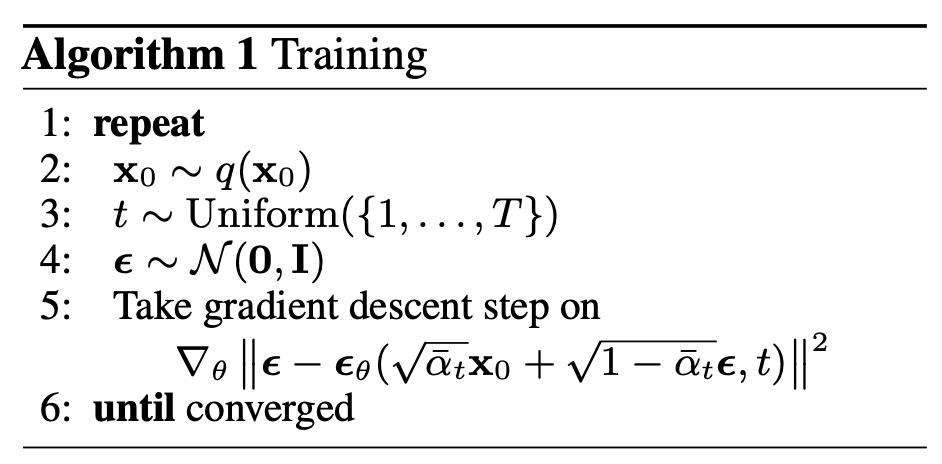


`DiffusionTrainer`: (1.5 pts)
- `calc_loss(clean_images: FloatTensor)` - необходимо внутри метода просемплировать время, далее просемплировать $x_t$, обработать батч, рассчитать лосс для обучения

In [ ]:
from torch_ema import ExponentialMovingAverage
import wandb
import math
import torchvision


class DiffusionTrainer:
    def __init__(
        self,
        ddpm: nn.Module,
        dynamic: DDPMDynamic,
        device: torch.device = torch.device('cpu')
    ):
        self.ddpm = ddpm
        self.dynamic = dynamic

        self.dynamic.to(device)
        self.ddpm.to(device)

        self.sampler = Sampler(ddpm, dynamic)
        self.sampler.to(device)

        self.ema = ExponentialMovingAverage(ddpm.parameters(), decay=0.999)

        self.device = device


        self.optimizer = torch.optim.AdamW(
            self.ddpm.parameters(),
            lr=2e-4,
            weight_decay=1e-2
        )

        self.step = 0

    def switch_to_ema(self) -> None:
        self.ema.store(self.ddpm.parameters())
        self.ema.copy_to(self.ddpm.parameters())

    def switch_back_from_ema(self) -> None:
        self.ema.restore(self.ddpm.parameters())

    def calc_loss(self, x_0: torch.Tensor) -> torch.Tensor:
        ts = self.dynamic.sample_time_on_device(x_0.shape[0], self.device)
        batch = {"x_0": x_0, "time": ts}
        fwd_process_result = self.dynamic(batch)
        x_t, eps = fwd_process_result["x_t"], fwd_process_result["eps"]
        eps_pred = self.ddpm(x_t, ts)

        return torch.mean((eps - eps_pred) ** 2)

    def log_metric(self, metric_name: str, loader_name: str, value: Union[float, torch.Tensor, wandb.Image]):
        wandb.log({f'{metric_name}/{loader_name}': value}, step=self.step)

    def optimizer_logic(self, loss: torch.Tensor) -> None:
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.ema.update(self.ddpm.parameters())

    def train(
            self,
            train_generator: Generator[Dict[str, Tensor], None, None],
            total_iters: int = 1000,
            project_name: str = 'discrete_time_ddpm',
            experiment_name: str = 'mnist_baseline'
        ) -> None:
        session = wandb.init(project=project_name, name=experiment_name)

        self.ddpm.train()

        for iter_idx in trange(1, 1 + total_iters):
            self.step = iter_idx

            batch = next(train_generator)
            batch = dict_to_device(batch, device=self.device)

            loss = self.calc_loss(x_0=batch['images'])
            self.log_metric('mse', 'train', loss)

            self.optimizer_logic(loss)

            if iter_idx % 1000 == 0:
                self.snapshot()

        self.ddpm.eval()
        self.switch_to_ema()

        session.finish()

    @torch.no_grad()
    def sample_images(
            self, batch_size: int,
            verbose: bool = False
    ) -> torch.Tensor:
        x_pred = self.sampler.sample((batch_size, 1, 32, 32), self.device, verbose)
        x_pred = postprocess_image(x_pred)
        return x_pred

    @torch.no_grad()
    def snapshot(self) -> None:
        prev_mode = self.ddpm.training

        self.ddpm.eval()
        self.switch_to_ema()

        images = self.sample_images(100).cpu()
        nrow = 10
        grid = torchvision.utils.make_grid(images, nrow=nrow).permute(1, 2, 0)
        grid = grid.data.numpy().astype(np.uint8)
        self.log_metric('images', 'from_noise', wandb.Image(grid))

        self.switch_back_from_ema()
        self.ddpm.train(prev_mode)

In [ ]:
from denoising_diffusion_pytorch import Unet
set_global_seed(42)
ddpm = Unet(
    dim=64,
    dim_mults=(1, 2, 4, 4),
    channels=1,
    flash_attn=True
)

In [ ]:
device = torch.device('cuda:0')

In [ ]:
trainer = DiffusionTrainer(
    ddpm,
    DDPMDynamic(),
    device
)

In [ ]:
generator = get_train_images_generator(128)

In [ ]:
trainer.train(
    generator,
    total_iters=5000
)

mse/train,█▃▂▂▂▁▁▁▁▁▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mse/train,3576.94971


  0%|          | 0/5000 [00:00<?, ?it/s]

mse/train,█▅▃▄▅▃▃▄▄▃▄▂▂▃▂▃▃▂▃▂▃▂▃▂▃▂▂▁▁▃▁▂▁▂▂▁▁▂▂▃
mse/train,0.01592


In [ ]:
trainer.switch_to_ema()
torch.save(ddpm.state_dict(), "./pretrained_ddpm_checkpoint.pth")

### В ноутбуке должны быть отображены графики лосса на обучении и изображения из функции snapshot во время обучения на итерациях 1000, 2000, 3000, 4000, 5000.

https://wandb.ai/vsevolodshurygin-higher-school-of-economics/discrete_time_ddpm

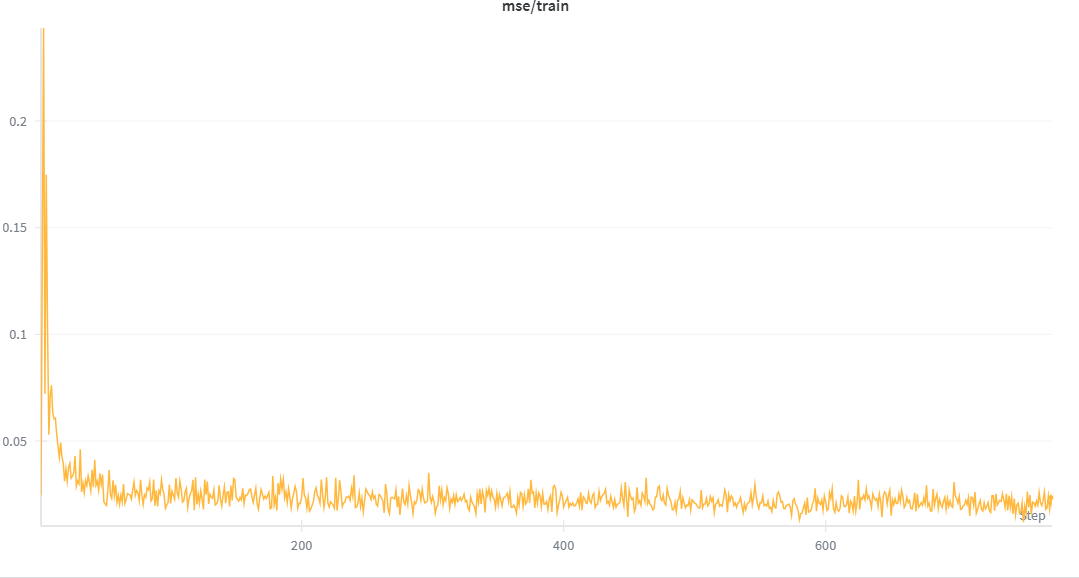

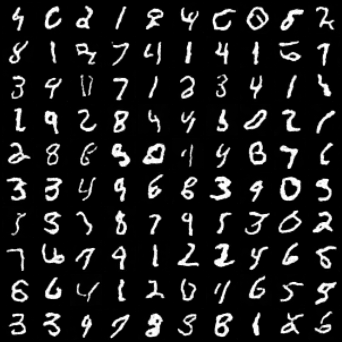

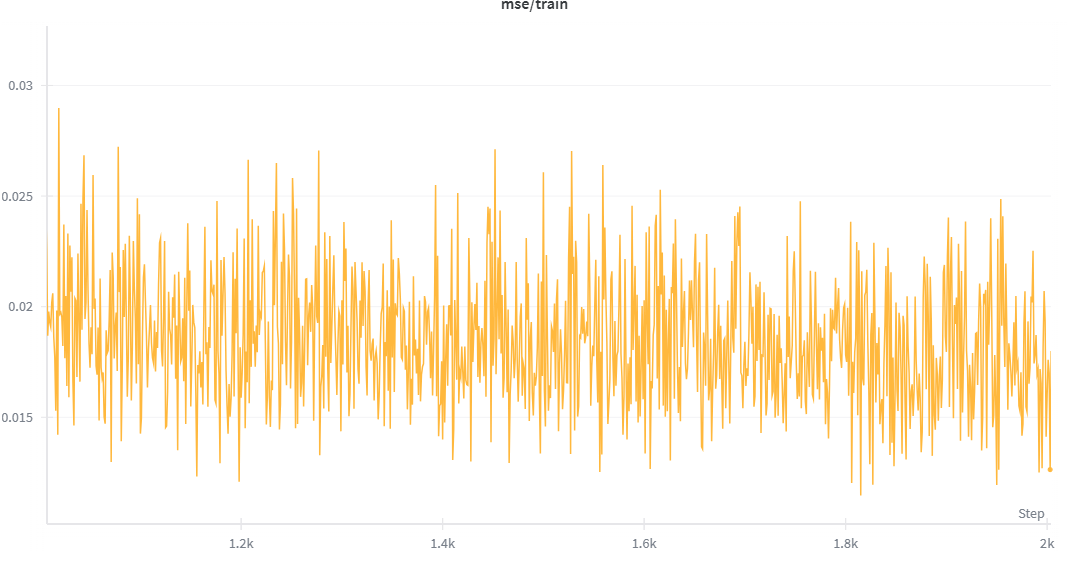

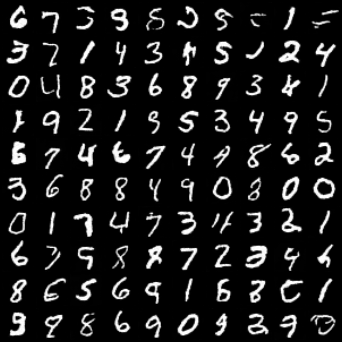

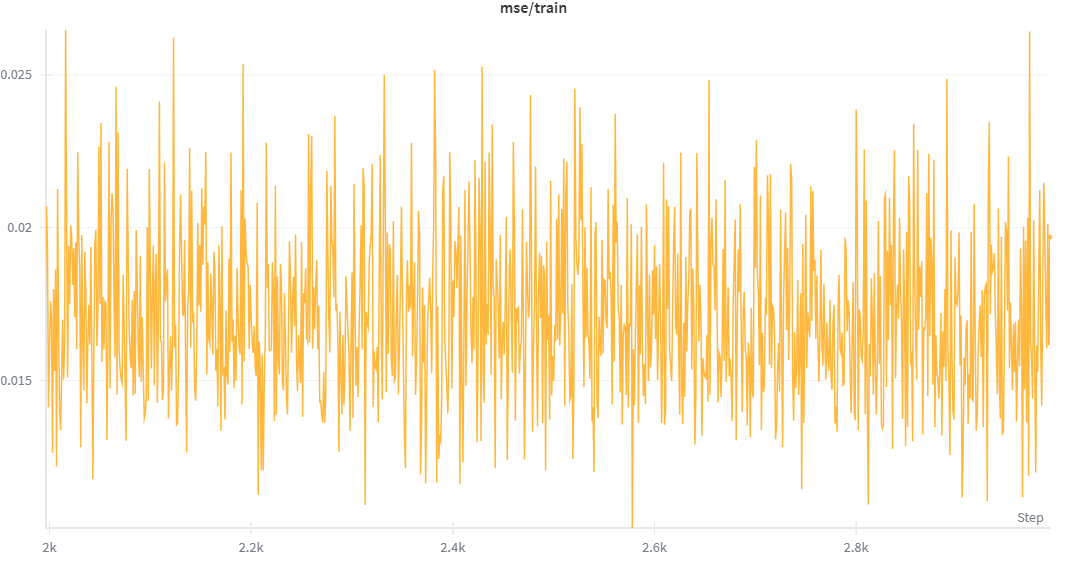

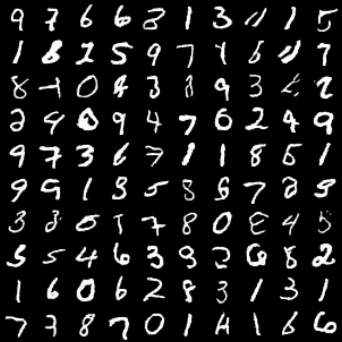

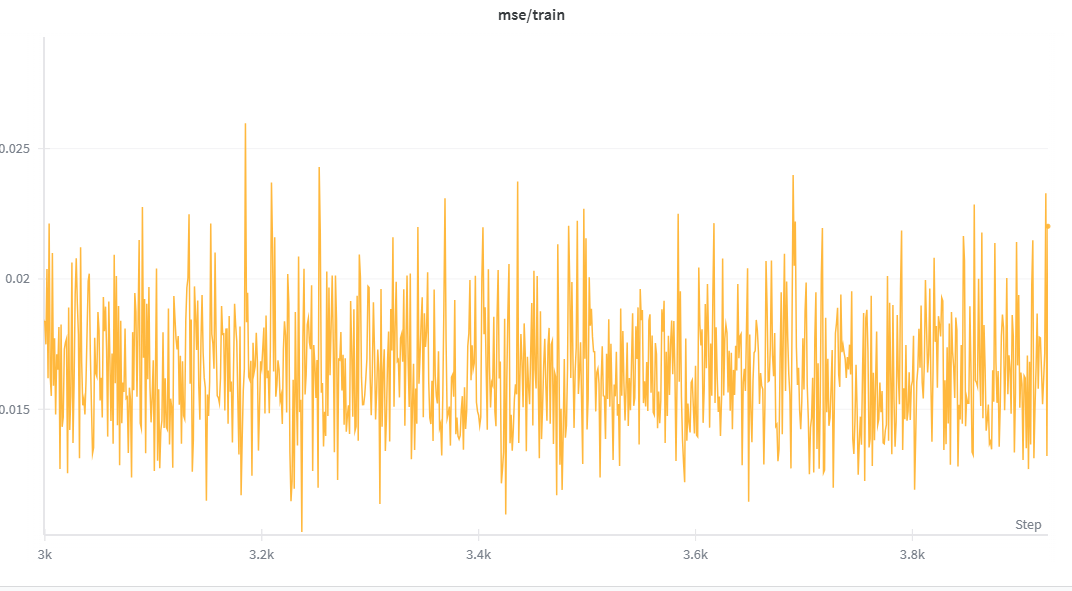

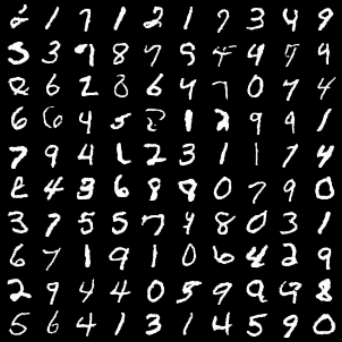

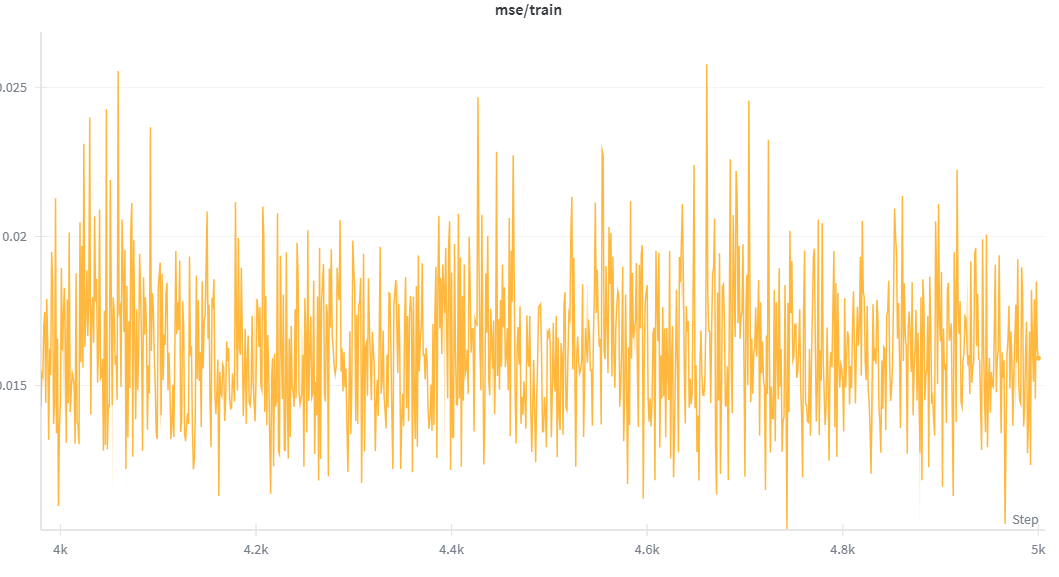

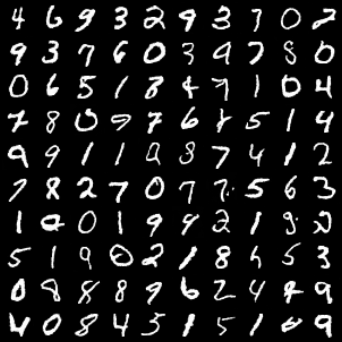

## Безусловная генерация (неплохих картинок - 0.5 pts)

  0%|          | 0/1000 [00:00<?, ?it/s]

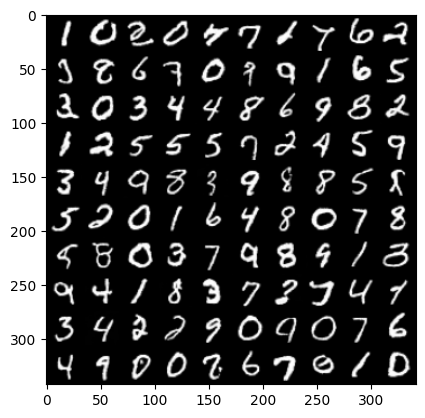

In [ ]:
from matplotlib import pyplot as plt
import math


def sample_images(
    sampler: Sampler, batch_size: int = 100,
    device = torch.device('cpu'),
    verbose: bool = True
):
    images = sampler.sample((batch_size, 1, 32, 32), device, True)
    images = postprocess_image(images)
    images = images.cpu()
    nrow = int(math.ceil(math.sqrt(batch_size)))
    grid = torchvision.utils.make_grid(images, nrow=nrow).permute(1, 2, 0)
    grid = grid.data.numpy().astype(np.uint8)
    return grid

grid = sample_images(trainer.sampler, 100, trainer.device)

plt.imshow(grid)

# Опишите ваши выводы/результаты: (1.5 pts)
- Из графиков лосса вижу, что сначала он круто убывает, после 1к шагов начинает колебаться около 0.2, продолжает осцилировать и после 4к шагов начинает колебаться около 0.15. Из этого думается, что 5к шагов вполне достаточно для обучения, поскольку в целом-то последние 4к шагов лосс находится в одном и том же диапазоне
- По картинкам вижу, что после 1к шагов цифры ещё нехило так скукуружены, но в результате после 5к шагов уже почти всё чётко: в большинстве картинок явно угадываются цифры, а загадочных иероглифов, клинописи и прочих артефактов не так много.
- При этом само наличие "артефактов" по построению почти неизбежно даже на таких простых примерах, тк мы пытаемся "выучить" распределение.

Выше вы использовали `ema` веса модели. Опишите, что это такое и для чего их используют:

Под EMA (экспоненциальное скользящее среднее) весов модели подразумевается техника, при которой во время обучения поддерживается отдельный набор весов, являющийся экспоненциально взвешенным скользящим средним всех предыдущих весов модели. Эта техника применяется для улучшения стабильности, обобщающей способности и сглаживания результатов, что особенно полезно при финальной оценке модели.

- Во время обучения существуют два набора весов:

Тренировочные веса: cтандартные веса модели, которые обновляются на каждом шаге обучения с помощью градиентного спуска (например, Adam или SGD).

EMA-веса (усреднённые веса): второй набор весов, который не участвует в процессе обратного распространения ошибки, а обновляется как взвешенное среднее между предыдущим значением EMA-весов и текущими тренировочными весами. Обновление EMA-весов происходит по следующей формуле: $$EMA_{weights}=\alpha \cdot EMA_{weights}+(1-\alpha )\cdot Training_{weights}$$ Здесь $alpha$ — коэффициент сглаживания, обычно очень близкий к 1 (например, 0,999 или 0,9999). Чем выше $alpha$, тем больше веса имеют старые значения и тем медленнее обновляется EMA.

- Как это работает: на каждом шаге обучения EMA-веса «догоняют» тренировочные веса, но делают это плавно и с инерцией. В результате EMA-веса представляют собой более стабильную, "усреднённую" версию тренировочных весов.

- В некоторых задачах, особенно в генеративных моделях (например, диффузионных), тренировочные веса могут сильно колебаться на поздних стадиях обучения. Использование EMA-весов позволяет сгладить эти колебания, что приводит к более стабильной работе модели. Усреднение весов может помочь "сгладить" ландшафт потерь и найти более широкие, "плоские" минимумы, которые, как известно, лучше обобщают на новых данных. Это часто приводит к более высокой производительности модели на проверочных данных, чем использование последних тренировочных весов.

- На финальном этапе, при использовании модели для предсказаний, часто вместо последних тренировочных весов применяются EMA-веса. Это позволяет получить более надёжные и качественные результаты.


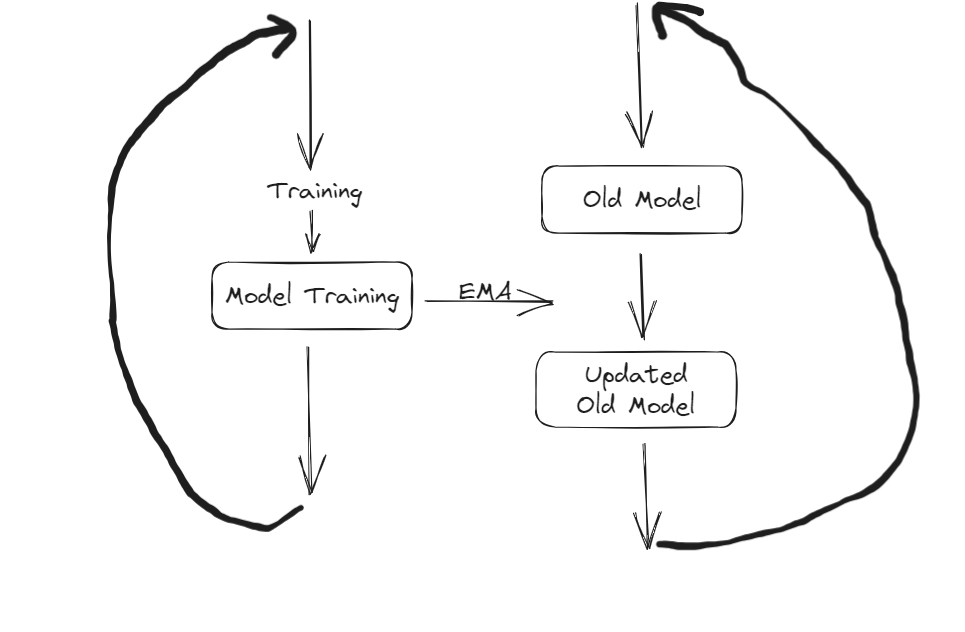

Большую часть кода нашёл в открытом источнике: https://github.com/astatarinov/university/blob/main/Bayesian%20methods/hw2/ddpm_hw_bmmo-TatarinovArtem.ipynb



